In [25]:


import math
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage
from scipy import signal
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from skimage.color import rgb2lab, rgba2rgb

In [26]:
NUM_BLOCK_INIT_V = 5
NUM_BLOCK_INIT_H=5


In [27]:
plt.rcParams['font.family'] = 'SimHei'
warnings.filterwarnings('ignore')

original_image = skimage.io.imread("test.png")
if original_image.shape[2] == 4:
    original_image = rgba2rgb(original_image)

h, w = original_image.shape[:2]

scale_factor = 1000 / max(w, h)  # 目标最大边长为800
new_w, new_h = int(w * scale_factor), int(h * scale_factor)
image = skimage.transform.resize(original_image, (new_h, new_w), anti_aliasing=True)


In [28]:
w, h, original_image.shape



(1234, 420, (420, 1234, 3))

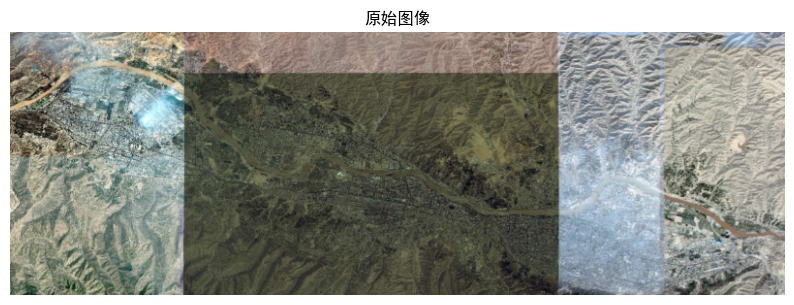

In [29]:

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title("原始图像")
plt.axis('off')
plt.show()
# skimage.io.imsave("thumb.png",(255*image).astype(np.uint8))

In [30]:
def detect_color_boundaries_vertical(image, num_blocks=2, require_grad_norm=True):
    image_lab = rgb2lab(image)
    L_channel = image_lab[:, :, 0]  # 亮度通道
    grad_x = np.abs(signal.convolve2d(L_channel, np.array([[-1, 0, 1]]), mode='same'))
    grad_smooth = gaussian_filter(grad_x, sigma=2)
    grad_norm = (grad_smooth - grad_smooth.min()) / (grad_smooth.max() - grad_smooth.min() + 1e-8)

    # 寻找梯度峰值（潜在边界位置）
    grad_profile = np.mean(grad_norm, axis=0)
    peaks, properties = find_peaks(grad_profile, height=0.1, distance=10)

    if len(peaks) < num_blocks - 1:
        peaks, properties = find_peaks(grad_profile, height=0.08, distance=8)

    if len(peaks) > 0:
        peak_heights = properties['peak_heights']
        sorted_indices = np.argsort(peak_heights)[::-1]  # 从高到低
        peaks = peaks[sorted_indices]

        # 只保留前几个最强的峰值
        peaks = peaks[:min(len(peaks), num_blocks)]
        # peaks = np.sort(peaks)  # 按位置排序
    if not require_grad_norm:
        return peaks
    return peaks, grad_profile, grad_norm


def detect_color_boundaries_horizontal(image, num_blocks=2, require_grad_norm=True):
    img_lab = rgb2lab(image)
    L_channel = img_lab[:, :, 0]  # 亮度通道
    grad_x = np.abs(signal.convolve2d(L_channel, np.array([[-1], [0], [1]]), mode='same'))
    grad_smooth = gaussian_filter(grad_x, sigma=2)
    grad_norm = (grad_smooth - grad_smooth.min()) / (grad_smooth.max() - grad_smooth.min() + 1e-8)

    # 寻找梯度峰值（潜在边界位置）
    grad_profile = np.mean(grad_norm, axis=1)
    peaks, properties = find_peaks(grad_profile, height=0.1, distance=10)

    if len(peaks) < num_blocks - 1:
        peaks, properties = find_peaks(grad_profile, height=0.08, distance=8)

    if len(peaks) > 0:
        peak_heights = properties['peak_heights']
        sorted_indices = np.argsort(peak_heights)[::-1]  # 从高到低
        peaks = peaks[sorted_indices]

        # 只保留前几个最强的峰值
        peaks = peaks[:min(len(peaks), num_blocks)]
        # peaks = np.sort(peaks)  # 按位置排序
    if not require_grad_norm:
        return peaks
    return peaks, grad_profile, grad_norm


In [31]:

peaks_v, grad_profile_v, grad_map_v = detect_color_boundaries_vertical(image, num_blocks=NUM_BLOCK_INIT_V)
peaks_h, grad_profile_h, grad_map_h = detect_color_boundaries_horizontal(image, num_blocks=NUM_BLOCK_INIT_H)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


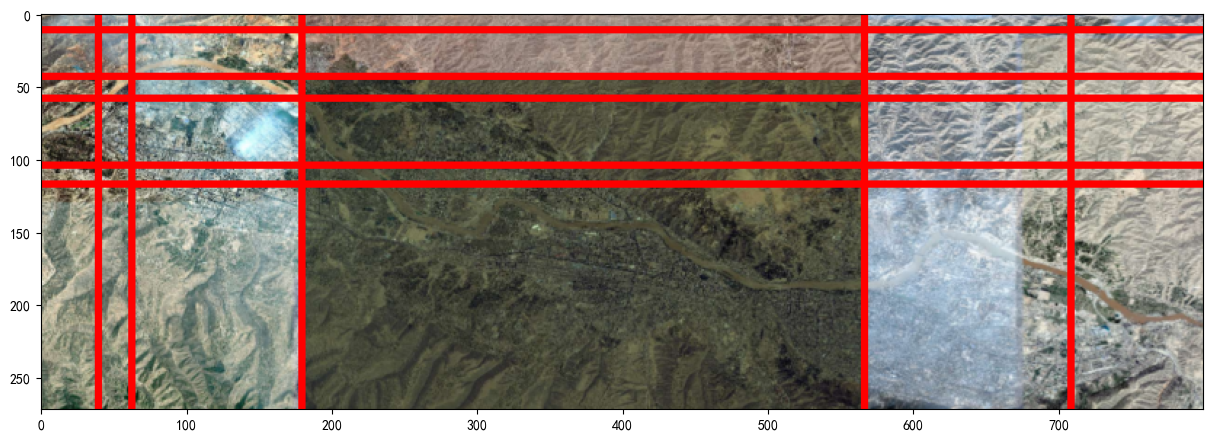

In [32]:
# print(peaks_v)
# print(peaks_h)
# plt.plot(grad_profile_h)
# plt.scatter(peaks_h, grad_profile_h[peaks_h], color='red', s=50, zorder=5)
# plt.title("垂直梯度分布 (检测到的边界用红点标记)")
# plt.xlabel("垂直位置 (像素)")
# plt.ylabel("梯度强度")
# plt.show()

# boundaries_v = [0] + list(peaks_v) + [image.shape[1]]
# boundaries_h = [0] + list(peaks_h) + [image.shape[0]]

# boundaries_v = [0] + list(x_divisions) + [image.shape[1]]
# boundaries_h = [0] + list(y_divisions) + [image.shape[0]]

# 可视化分割结果
plt.figure(figsize=(15, 8))

# 绘制边界线
result_image = image.copy()
for i, boundary_v in enumerate(peaks_v):
    cv2.line(result_image, (boundary_v, 0), (boundary_v, image.shape[0]),
             (255, 0, 0), 3)
for i, boundary_h in enumerate(peaks_h):
    cv2.line(result_image, (0, boundary_h), (image.shape[1], boundary_h),
             (255, 0, 0), 3)

plt.imshow(result_image)
plt.show()


In [33]:
print("请选择需要保留的分割线序号（从1开始），若有多个数据，请用空格隔开")
choose_v_list = [int(i)-1 for i in input("竖直分割线：").strip().split(" ") if i.isdigit()]
choose_h_list = [int(i)-1 for i in input("水平分割线：").strip().split(" ") if i.isdigit()]
choose_v_mask = np.zeros(NUM_BLOCK_INIT_V, dtype=bool)
choose_h_mask = np.zeros(NUM_BLOCK_INIT_H, dtype=bool)
for i in choose_v_list:
    try:
        choose_v_mask[i]=True
    except:
        print(f"{i} is an error index for vertical list: {choose_v_list}")
for i in choose_h_list:
    try:
        choose_h_mask[i]=True
    except:
        print(f"{i} is an error index for horizontal list: {choose_h_list}")


请选择需要保留的分割线序号（从1开始），若有多个数据，请用空格隔开


In [34]:
peaks_v_sorted = np.sort(peaks_v)[choose_v_mask]
peaks_h_sorted = np.sort(peaks_h)[choose_h_mask]
print(peaks_v_sorted, peaks_h_sorted)
peaks_v_sorted_original = ((peaks_v_sorted / scale_factor).astype(np.int32)).tolist()
peaks_h_sorted_original = ((peaks_h_sorted / scale_factor).astype(np.int32)).tolist()
print(peaks_v_sorted_original, peaks_h_sorted_original)
dx = math.ceil(w * 0.008)
dy = math.ceil(h * 0.008)

[179 566 708] [43]
[276, 873, 1092] [66]


In [35]:
w, h, dx, dy, peaks_v_sorted_original, peaks_h_sorted_original


(1234, 420, 10, 4, [276, 873, 1092], [66])

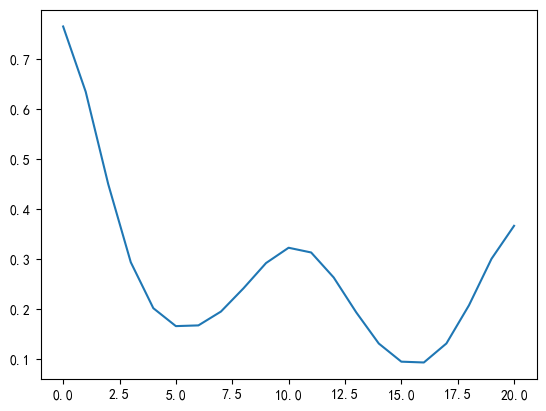

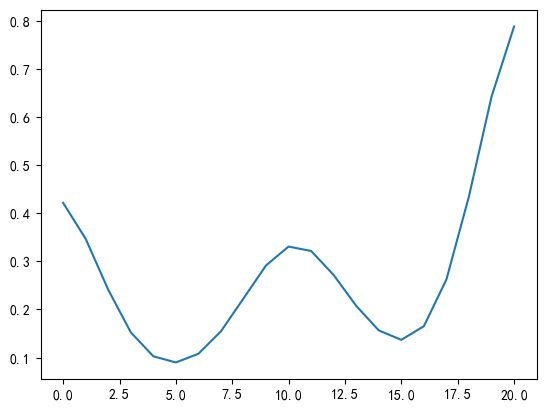

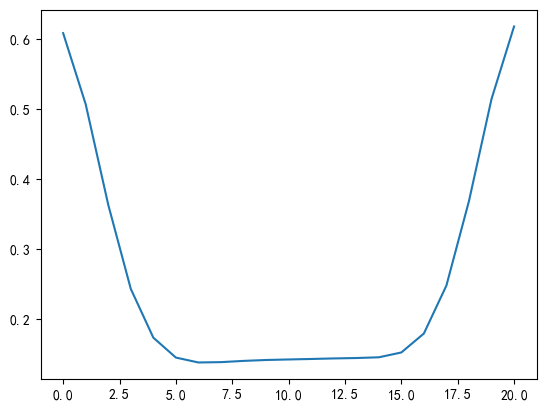

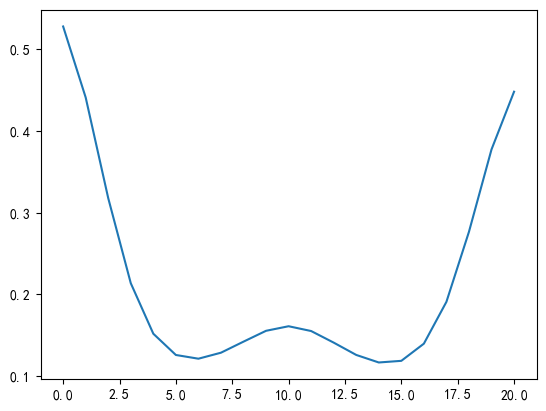

[276, 873, 1092] [66]


In [36]:
def detect_original_vertical(x, dx):
    global original_image, w
    x1 = max(0, x - dx)
    x2 = min(x + dx, w)
    img = original_image[:, x1:x2 + 1, :]
    p_v, grad_profile_v, grad_norm_v = detect_color_boundaries_vertical(img, num_blocks=3)
    plt.plot(grad_profile_v)
    plt.show()
    if len(p_v) ==0 :
        return x

    return p_v[0].tolist() + x1


def detect_original_horizontal(y, dy):
    global original_image, h
    y1, y2 = max(0, y - dy), min(y + dy, h)
    img = original_image[y1:y2 + 1, :, :]
    p_h, grad_profile_h, grad_norm_h = detect_color_boundaries_horizontal(img, num_blocks=3)
    plt.plot(grad_profile_h)
    plt.show()
    if len(p_h) ==0 :
        return y
    return p_h[0].tolist() + y1


x_divisions = []
y_divisions = []

for x in peaks_v_sorted_original:
    x_divisions.append(detect_original_vertical(x, dx))
for y in peaks_h_sorted_original:
    y_divisions.append(detect_original_horizontal(y, dx))
    # time.sleep(10)

print(x_divisions, y_divisions)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


x_divisions [276, 873, 1092]
y_divisions [66]


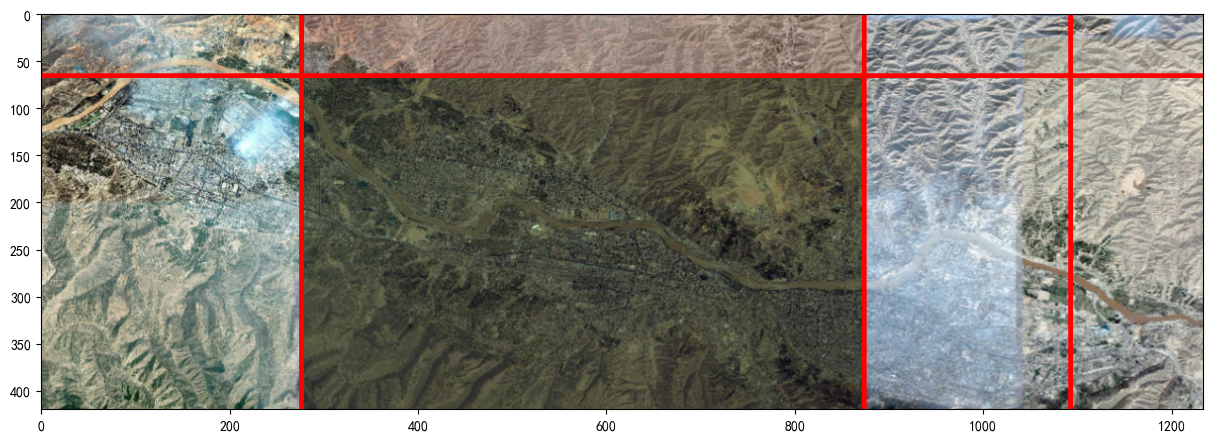

In [37]:
print("x_divisions", x_divisions)
print("y_divisions", y_divisions)
# 可视化分割结果
plt.figure(figsize=(15, 8))

# 绘制边界线
result_image = original_image.copy()
for i, boundary_v in enumerate(x_divisions):  # 跳过第一个和最后一个
    cv2.line(result_image, (boundary_v, 0), (boundary_v, h),
             (255, 0, 0), 3)
for i, boundary_h in enumerate(y_divisions):  # 跳过第一个和最后一个
    cv2.line(result_image, (0, boundary_h), (w, boundary_h),
             (255, 0, 0), 3)

plt.imshow(result_image)
plt.show()


In [38]:
peaks_v_sorted, peaks_h_sorted


(array([179, 566, 708]), array([43]))

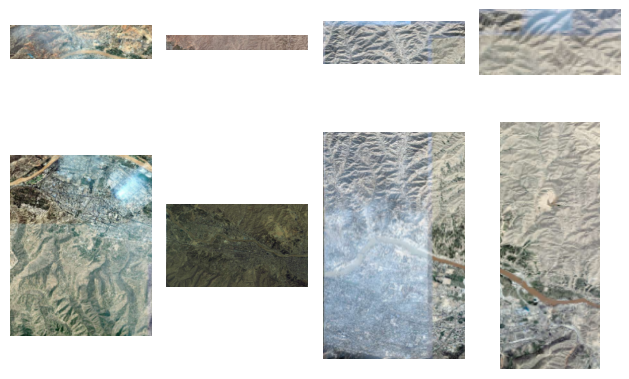

In [39]:
plt_col_len = len(x_divisions) + 1
plt_row_len = len(y_divisions) + 1
plt_slice_v = [0] + list(peaks_v_sorted) + [image.shape[1]]
plt_slice_h = [0] + list(peaks_h_sorted) + [image.shape[0]]

for i in range(plt_row_len):
    for j in range(plt_col_len):
        plt.subplot(plt_row_len, plt_col_len, i * plt_col_len + j + 1)
        plt.imshow(image[plt_slice_h[i]:plt_slice_h[i + 1], plt_slice_v[j]:plt_slice_v[j + 1]])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [40]:
[basic_block_h_idx,basic_block_v_idx]=[int(i)-1 for i in input("请依次输入基准图块的行号、列号，用空格分开：").strip().split(" ")]


In [41]:
# basic_block_idx = 8 - 1
# basic_block_h_idx = basic_block_idx // plt_col_len
# basic_block_v_idx = basic_block_idx % plt_col_len

original_slice_v = [0] + list(x_divisions) + [w]
original_slice_h = [0] + list(y_divisions) + [h]

print(original_slice_v, original_slice_h)


[0, 276, 873, 1092, 1234] [0, 66, 420]


0 0
0 1
0 2
0 3
1 0
1 2
1 3


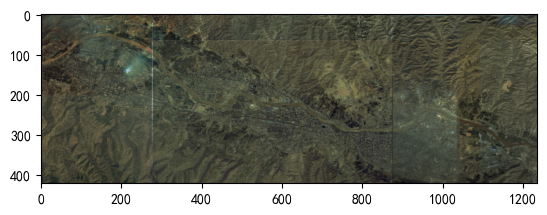

In [42]:
for i in range(plt_row_len):
    for j in range(plt_col_len):
        if (i,j) != (basic_block_h_idx,basic_block_v_idx):
            print(i,j)
            original_image[
                    original_slice_h[i]:original_slice_h[i + 1],
                    original_slice_v[j]:original_slice_v[j + 1]
                ] = skimage.exposure.match_histograms(
                original_image[
                    original_slice_h[i]:original_slice_h[i + 1],
                    original_slice_v[j]:original_slice_v[j + 1]
                ],
                original_image[
                    original_slice_h[basic_block_h_idx]:original_slice_h[basic_block_h_idx + 1],
                    original_slice_v[basic_block_v_idx]:original_slice_v[basic_block_v_idx + 1]
                ], channel_axis=-1)


plt.imshow(original_image)
plt.show()



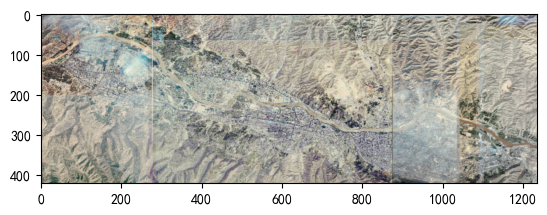

In [21]:
# 线
for i in range(plt_row_len-1):
    original_image[
            y_divisions[i]-dy:y_divisions[i]+dy,
            :
        ] = skimage.exposure.match_histograms(
        original_image[
            y_divisions[i]-dy:y_divisions[i]+dy,
            :
        ],
        original_image[
            original_slice_h[basic_block_h_idx]:original_slice_h[basic_block_h_idx + 1],
            original_slice_v[basic_block_v_idx]:original_slice_v[basic_block_v_idx + 1]
        ]
        , channel_axis=-1)

for j in range(plt_col_len-1):
    original_image[
            :,
            x_divisions[j]-dx:x_divisions[j]+dx
        ] = skimage.exposure.match_histograms(
        original_image[
            :,
            x_divisions[j]-dx:x_divisions[j]+dx
        ],
        original_image[
            original_slice_h[basic_block_h_idx]:original_slice_h[basic_block_h_idx + 1],
            original_slice_v[basic_block_v_idx]:original_slice_v[basic_block_v_idx + 1]
        ]
        ,channel_axis=-1)

plt.imshow(original_image)
plt.show()

In [ ]:


# # 可视化梯度分布
# plt.figure(figsize=(12, 8))

# plt.subplot(2, 2, 1)
# plt.imshow(image)
# plt.title("原始图像")
# plt.axis('off')

# plt.subplot(2, 2, 3)
# plt.imshow(grad_map_v, cmap='hot')
# plt.title("梯度图 (颜色边界强度)")
# plt.axis('off')

# # plt.subplot(2, 2, 4)
# # plt.imshow(grad_map_h, cmap='hot')
# # plt.title("梯度图 (颜色边界强度)")
# # plt.axis('off')

# plt.subplot(2, 2, 2)
# plt.plot(grad_profile_v)
# plt.scatter(peaks_v, grad_profile_v[peaks_v], color='red', s=50, zorder=5)
# plt.title("水平梯度分布 (检测到的边界用红点标记)")
# plt.xlabel("水平位置 (像素)")
# plt.ylabel("梯度强度")

# plt.subplot(2, 2, 4)
plt.plot(grad_profile_h)
plt.scatter(peaks_h, grad_profile_h[peaks_h], color='red', s=50, zorder=5)
plt.title("垂直梯度分布 (检测到的边界用红点标记)")
plt.xlabel("垂直位置 (像素)")
plt.ylabel("梯度强度")
plt.show()

# plt.tight_layout()
# plt.show()


# print(f"检测到 {len(peaks_v)} 个潜在边界点: {peaks_v}")

# 添加图像左右边界
boundaries_v = [0] + list(peaks_v) + [image.shape[1]]
boundaries_h = [0] + list(peaks_h) + [image.shape[0]]

# 可视化分割结果
plt.figure(figsize=(15, 8))

# 绘制边界线
result_image = image.copy()
for i, boundary_v in enumerate(boundaries_v[1:-1]):  # 跳过第一个和最后一个
    cv2.line(result_image, (boundary_v, 0), (boundary_v, image.shape[0]),
             (255, 0, 0), 3)
for i, boundary_h in enumerate(boundaries_h[1:-1]):  # 跳过第一个和最后一个
    cv2.line(result_image, (0, boundary_h), (image.shape[1], boundary_h),
             (255, 0, 0), 3)
    print(1)
plt.imshow(result_image)
plt.show()

# plt.subplot(1, 2, 1)
# plt.imshow(result_image)
# plt.title(f"检测到的边界 (共{len(boundaries) - 1}个区块)")
# plt.axis('off')

# # 绘制每个区块
# plt.subplot(1, 2, 2)
# for i in range(len(boundaries) - 1):
#     left, right = boundaries[i], boundaries[i + 1]
#     if right - left > 10:  # 只显示有效宽度的区块
#         plt.plot([left, right], [i, i], linewidth=20,
#                  color='C' + str(i % 10), label=f'区块 {i + 1}')
# plt.xlim(0, image.shape[1])
# plt.ylim(-1, len(boundaries))
# plt.gca().invert_yaxis()
# plt.title("区块分布")
# plt.xlabel("水平位置")
# plt.ylabel("区块序号")
# plt.legend()

# plt.tight_layout()
# plt.show()

# # 提取并显示每个区块
# print(f"\n提取的区块信息:")
# plt.figure(figsize=(15, 3))
# for i in range(len(boundaries) - 1):
#     left, right = boundaries[i], boundaries[i + 1]
#     if right - left > 10:  # 有效区块
#         segment = image[:, left:right, :]

#         plt.subplot(1, len(boundaries) - 1, i + 1)
#         plt.imshow(segment)
#         plt.title(f"区块 {i + 1}\n宽度: {right - left}px")
#         plt.axis('off')

#         print(f"区块 {i + 1}: 位置 [{left}, {right}], 宽度 {right - left}px")

# plt.tight_layout()
# plt.show()

